# 🌐 Network Packet Loss — Root Cause Classification

**Dataset:** NS3-like Synthetic Packet Loss Dataset (50,000 rows)

**Objective:** Predict the **root cause** of packet loss/behavior in a wireless network simulation.

**Target:** `cause_label` with 5 classes:
- `benign` — Normal expected behavior
- `congestion` — Network overload (queue overflow, buffer full)
- `mobility` — Node movement issues (link break, handoff timeout)
- `malicious` — Attack behavior (blackhole, greyhole, selective forward)
- `interference` — Signal/PHY issues (collision, phy_rx_error)

**Models:** XGBoost (baseline) + TabNet (deep learning) + Comparison

---

## 📦 Step 1: Install Dependencies

In [1]:
# Install required libraries
!pip install xgboost pytorch-tabnet scikit-learn imbalanced-learn shap matplotlib seaborn -q
print('✅ All libraries installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.4 MB/s eta 0:00:00
✅ All libraries installed!


## 📁 Step 2: Upload & Load Dataset

In [2]:
# Upload your CSV file
from google.colab import files
uploaded = files.upload()  # Upload: ns3_like_packet_loss_causes_v1_50k.csv

Saving ns3_like_packet_loss_causes_v2_50k.csv to ns3_like_packet_loss_causes_v2_50k.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('ns3_like_packet_loss_causes_v2_50k.csv')

print(f'Dataset Shape: {df.shape}')
print(f'\nTarget Distribution (cause_label):')
vc = df['cause_label'].value_counts()
for cls, cnt in vc.items():
    print(f'  {cls:25s}: {cnt:6d} ({cnt/len(df)*100:.1f}%)')
df.head(3)

Dataset Shape: (50000, 50)

Target Distribution (cause_label):
  mobility                 :  10000 (20.0%)
  congestion               :  10000 (20.0%)
  interference             :  10000 (20.0%)
  malicious                :  10000 (20.0%)
  benign                   :  10000 (20.0%)


,run_id,ns3_seed,sim_area_m,node_count,sim_duration_s,mobility_model,routing,transport,app,ttl_hops,...,split,mobility_model_enc,routing_enc,transport_enc,app_enc,phy_enc,sim_area_m_enc,mac_tx_failed,queue_drops,sim_area_numeric
0,81,81,250x250,40,600,RandomWaypoint,OLSR,UDP,CBR,5,...,train,0,0,0,0,0,1,0.0,0.0,250.0
1,70,70,250x250,40,600,RandomWaypoint,OLSR,UDP,CBR,5,...,train,0,0,0,0,0,1,0.0,0.0,250.0
2,28,28,150x150,20,600,RandomWaypoint,OLSR,UDP,CBR,5,...,train,0,0,0,0,0,0,0.0,0.0,150.0


## 🔍 Step 3: Exploratory Data Analysis (EDA)

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution bar plot
vc = df['cause_label'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#3498db', '#e67e22', '#9b59b6']
axes[0].bar(vc.index, vc.values, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Class Distribution — cause_label', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cause Label')
axes[0].set_ylabel('Count')
for i, (cls, cnt) in enumerate(vc.items()):
    axes[0].text(i, cnt + 100, f'{cnt}\n({cnt/len(df)*100:.1f}%)', ha='center', fontsize=9)

# Pie chart
axes[1].pie(vc.values, labels=vc.index, autopct='%1.1f%%', colors=colors,
            startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution — Pie Chart', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Class Distribution plotted')

✅ Class Distribution plotted


In [63]:
# Feature distributions by cause_label
key_features = ['rssi_dbm', 'snr_db', 'channel_busy_ratio', 'queue_len_norm',
                'mac_retries', 'link_changes_per_s', 'delay_ms', 'PRR']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    for label in df['cause_label'].unique():
        subset = df[df['cause_label'] == label][feat]
        axes[i].hist(subset, bins=30, alpha=0.5, label=label, density=True)
    axes[i].set_title(f'{feat}', fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].legend(fontsize=7)

plt.suptitle('Feature Distributions by Cause Label', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Feature distributions plotted')

✅ Feature distributions plotted


In [65]:
# Correlation heatmap of numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove leakage and ID cols for correlation
exclude = ['run_id', 'ns3_seed', 'src_id', 'dst_id', 'flow_id',
           'rx_success', 'loss_occurred', 'queue_drops']
numeric_cols = [c for c in numeric_cols if c not in exclude]

plt.figure(figsize=(16, 12))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0,
            linewidths=0.3, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Correlation heatmap plotted')

✅ Correlation heatmap plotted


## 🔧 Step 4: Preprocessing

In [66]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# ── Drop leakage + identifier columns ────────────────────
LEAKAGE_COLS = [
    'drop_reason',       # direct sub-label of cause_label
    'loss_occurred',     # derived from cause_label
    'qc_flag',           # QC flag
    'queue_drops',       # reveals the drop event
]
ID_COLS = [
    'run_id', 'ns3_seed', 'timestamp_s',
    'sim_area_m', 'sim_duration_s', 'split',
]

# Remove leakage/regime features that cause 100% accuracy
REGIME_LEAKAGE = [
    'pps',              # changes per regime (5 vs 100)
    'tx_power_dbm',     # changes per regime (20 vs 4 dBm)
    'speed_mps',        # changes per regime (1.5 vs 12 m/s)
    'mobility_model_enc', 'routing_enc',
    'transport_enc', 'app_enc', 'phy_enc',
    'sim_area_numeric', 'sim_area_m_enc',
    'node_count', 'ttl_hops',
    'mobility_model', 'routing', 'transport',
    'app', 'phy', 'packet_size_bytes',
    'mac_tx_failed', 'queue_drops',
    'backoff_slots', 'Peta', 'PM', 'PQ', 'ETX',
]

TARGET = 'cause_label'

# Drop all unwanted columns (ignore missing)
all_drop = LEAKAGE_COLS + ID_COLS + REGIME_LEAKAGE
all_drop = [c for c in all_drop if c in df.columns]
df_model = df.drop(columns=all_drop).copy()

print(f'Columns after dropping: '
      f'{df_model.shape[1]-1} features + 1 target')

# ── Encode remaining categoricals ────────────────────────
CAT_COLS = [c for c in df_model.columns
            if df_model[c].dtype == 'object'
            and c != TARGET]
print(f'Encoding categoricals: {CAT_COLS}')

label_encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(
        df_model[col].astype(str))
    label_encoders[col] = le

# ── Encode target ─────────────────────────────────────────
target_encoder = LabelEncoder()
df_model[TARGET] = target_encoder.fit_transform(
    df_model[TARGET])
CLASS_NAMES = target_encoder.classes_
print(f'\nClasses: {dict(zip(CLASS_NAMES, target_encoder.transform(CLASS_NAMES)))}')

# ── Train/Test split ──────────────────────────────────────
FEATURE_COLS = [c for c in df_model.columns
                if c != TARGET]

X = df_model[FEATURE_COLS].fillna(0).values
y = df_model[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

mal_idx = list(CLASS_NAMES).index('malicious')

print(f'\nX_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')

Columns after dropping: 15 features + 1 target
Encoding categoricals: []

Classes: {'benign': np.int64(0), 'congestion': np.int64(1), 'interference': np.int64(2), 'malicious': np.int64(3), 'mobility': np.int64(4)}

X_train: (40000, 15)
X_test:  (10000, 15)
Features (15): ['noise_floor_dbm', 'rssi_dbm', 'snr_db', 'neighbor_count', 'channel_busy_ratio', 'queue_len_norm', 'link_changes_per_s', 'collisions', 'mac_retries', 'PRR', 'delay_ms', 'jitter_ms', 'mac_tx_attempts', 'mac_tx_success', 'queue_drops_rate']


#new code

In [24]:
!pip install imbalanced-learn xgboost scikit-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score)
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import shap

print("✅ All libraries loaded!")

✅ All libraries loaded!


#Cell 1 — Train All 4 Models

In [25]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.utils.class_weight import compute_sample_weight
import time, warnings
warnings.filterwarnings('ignore')

results = {}

# ══════════════════════════════════════════════════════
# MODEL 1: XGBoost
# ══════════════════════════════════════════════════════
print("🌲 Training XGBoost...")
sw = compute_sample_weight('balanced', y=y_train)
xgb = XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', random_state=42,
    n_jobs=-1, verbosity=0
)
t0 = time.time()
xgb.fit(X_train, y_train, sample_weight=sw)
results['XGBoost'] = {
    'model': xgb, 'preds': xgb.predict(X_test),
    'time': time.time()-t0, 'color': '#2196F3'
}
print(f"  ✅ Done {results['XGBoost']['time']:.1f}s | F1-Macro: {f1_score(y_test, results['XGBoost']['preds'], average='macro')*100:.2f}%")

# ══════════════════════════════════════════════════════
# MODEL 2: Random Forest
# ══════════════════════════════════════════════════════
print("\n🌳 Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=500, max_depth=None,
    class_weight='balanced', random_state=42, n_jobs=-1
)
t0 = time.time()
rf.fit(X_train, y_train)
results['Random Forest'] = {
    'model': rf, 'preds': rf.predict(X_test),
    'time': time.time()-t0, 'color': '#4CAF50'
}
print(f"  ✅ Done {results['Random Forest']['time']:.1f}s | F1-Macro: {f1_score(y_test, results['Random Forest']['preds'], average='macro')*100:.2f}%")

# ══════════════════════════════════════════════════════
# MODEL 3: SVM
# ══════════════════════════════════════════════════════
print("\n🔷 Training SVM (uses scaled features)...")
from sklearn.svm import SVC
svm = SVC(
    kernel='rbf', C=10, gamma='scale',
    class_weight='balanced', probability=True,
    random_state=42
)
t0 = time.time()
# SVM needs scaled data — use X_train_scaled / X_test_scaled
svm.fit(X_train_scaled, y_train)
results['SVM'] = {
    'model': svm, 'preds': svm.predict(X_test_scaled),
    'time': time.time()-t0, 'color': '#FF9800'
}
print(f"  ✅ Done {results['SVM']['time']:.1f}s | F1-Macro: {f1_score(y_test, results['SVM']['preds'], average='macro')*100:.2f}%")

# ══════════════════════════════════════════════════════
# MODEL 4: MLP
# ══════════════════════════════════════════════════════
print("\n🧠 Training MLP...")
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu', solver='adam',
    learning_rate_init=0.001,
    max_iter=300, early_stopping=True,
    validation_fraction=0.1, n_iter_no_change=15,
    random_state=42
)
t0 = time.time()
mlp.fit(X_train_scaled, y_train)
results['MLP'] = {
    'model': mlp, 'preds': mlp.predict(X_test_scaled),
    'time': time.time()-t0, 'color': '#9C27B0'
}
print(f"  ✅ Done {results['MLP']['time']:.1f}s | F1-Macro: {f1_score(y_test, results['MLP']['preds'], average='macro')*100:.2f}%")

print("\n" + "="*60)
print("📊 SUMMARY")
print("="*60)
print(f"{'Model':<20} {'Accuracy':>10} {'F1-Macro':>10} {'Time(s)':>10}")
print("-"*60)
for name, r in results.items():
    acc = accuracy_score(y_test, r['preds'])
    f1  = f1_score(y_test, r['preds'], average='macro')
    print(f"{name:<20} {acc*100:>9.2f}% {f1*100:>9.2f}% {r['time']:>10.1f}")

🌲 Training XGBoost...
  ✅ Done 59.2s | F1-Macro: 84.20%

🌳 Training Random Forest...
  ✅ Done 40.3s | F1-Macro: 84.54%

🔷 Training SVM (uses scaled features)...
  ✅ Done 128.8s | F1-Macro: 82.71%

🧠 Training MLP...
  ✅ Done 62.1s | F1-Macro: 82.79%

📊 SUMMARY
Model                  Accuracy   F1-Macro    Time(s)
------------------------------------------------------------
XGBoost                  84.21%     84.20%       59.2
Random Forest            84.55%     84.54%       40.3
SVM                      83.31%     82.71%      128.8
MLP                      82.97%     82.79%       62.1


In [26]:
# Run this cell to confirm which dataset is loaded
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns[:10])}")
print(f"Sample run_id values: {df['run_id'].unique()[:5]}")
print(f"Sample sim_area values: {df['sim_area_m'].unique()[:5] if 'sim_area_m' in df.columns else 'not found'}")

Dataset shape: (50000, 50)
Columns: ['run_id', 'ns3_seed', 'sim_area_m', 'node_count', 'sim_duration_s', 'mobility_model', 'routing', 'transport', 'app', 'ttl_hops']
Sample run_id values: [81 70 28 80 10]
Sample sim_area values: ['250x250' '150x150' '500x500']


#Cell 2 — Classification Reports

In [28]:
for name, r in results.items():
    print(f"\n{'='*60}")
    print(f"📊 {name} — Classification Report")
    print('='*60)
    print(classification_report(y_test, r['preds'], target_names=CLASS_NAMES))


📊 XGBoost — Classification Report
              precision    recall  f1-score   support

      benign       1.00      1.00      1.00      2000
  congestion       1.00      1.00      1.00      2000
interference       1.00      1.00      1.00      2000
   malicious       0.60      0.62      0.61      2000
    mobility       0.61      0.59      0.60      2000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000


📊 Random Forest — Classification Report
              precision    recall  f1-score   support

      benign       1.00      1.00      1.00      2000
  congestion       1.00      1.00      1.00      2000
interference       1.00      1.00      1.00      2000
   malicious       0.61      0.62      0.62      2000
    mobility       0.62      0.61      0.61      2000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
w

#Cell 3 — Confusion Matrices (2×2 Grid)

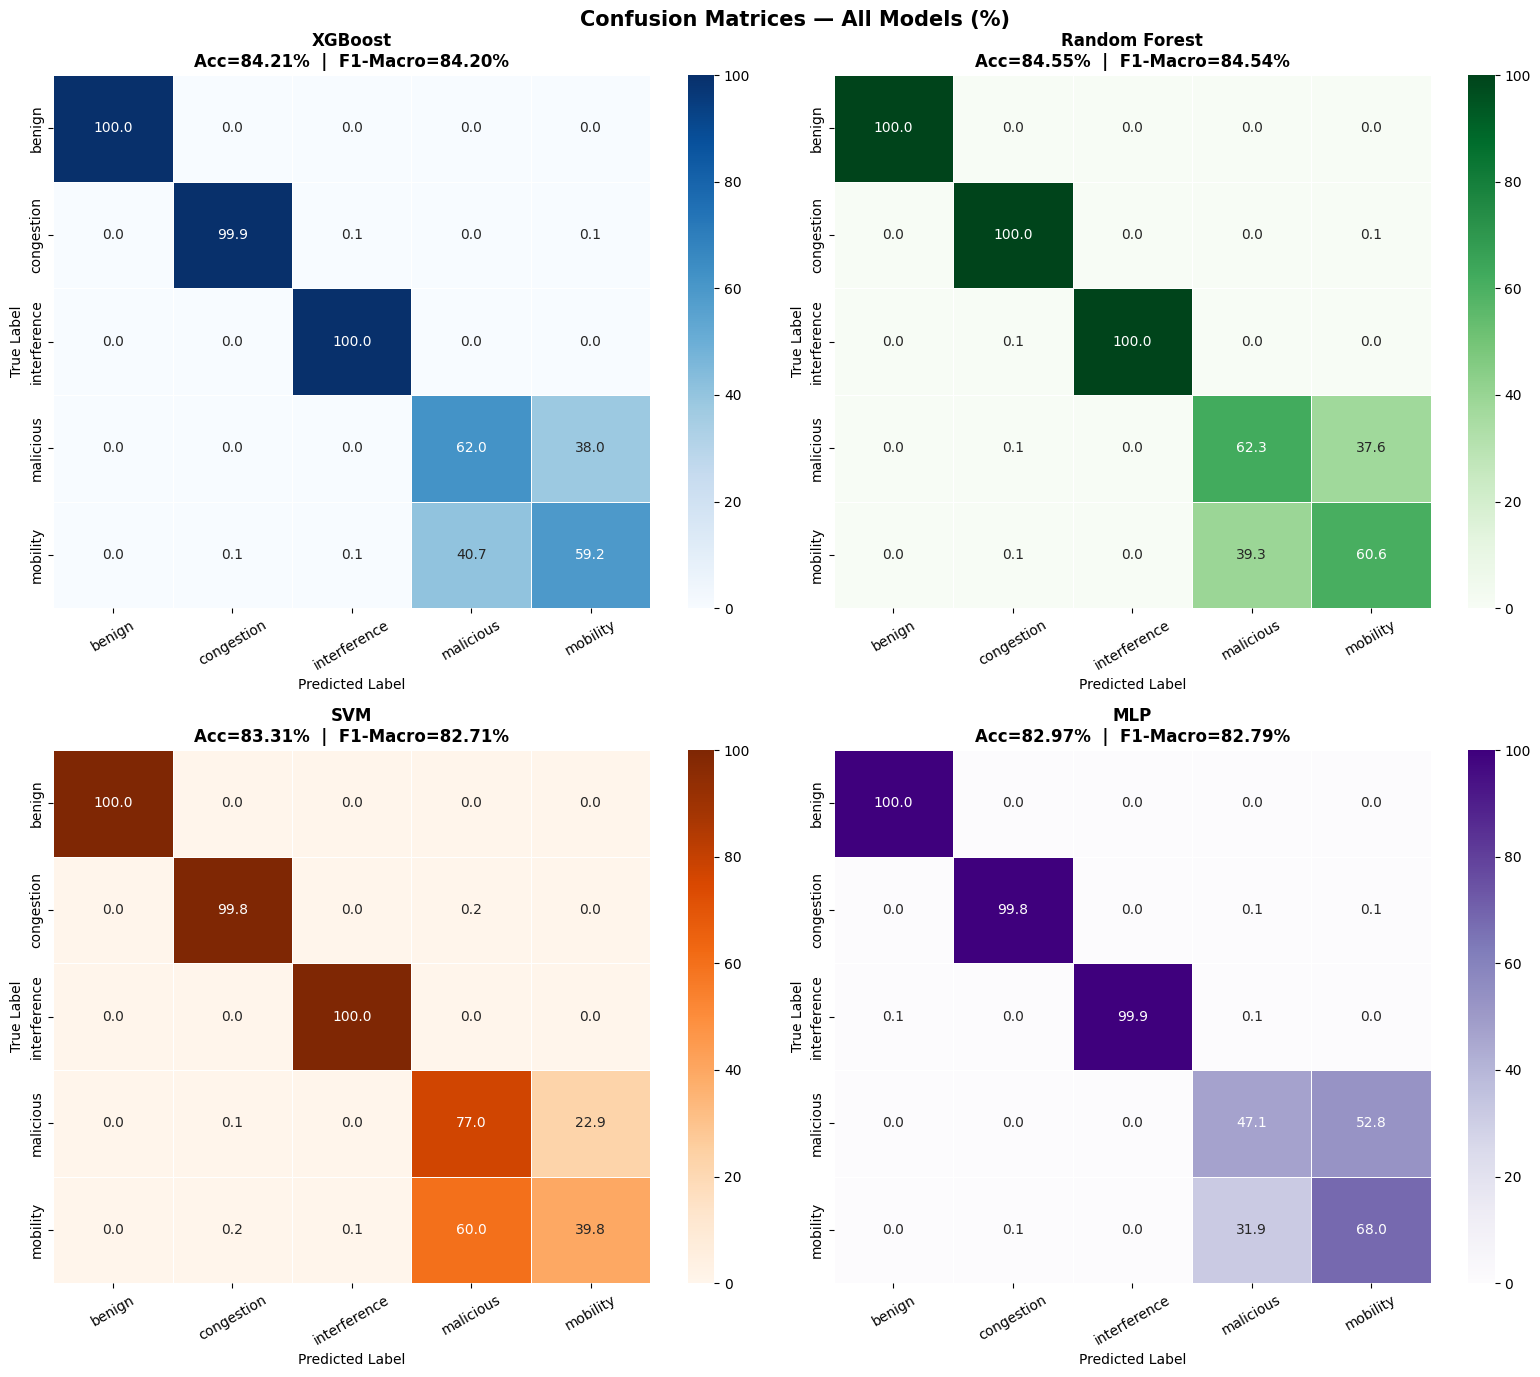

✅ Confusion matrices saved


In [29]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()
cmaps = ['Blues', 'Greens', 'Oranges', 'Purples']

for ax, (name, r), cmap in zip(axes, results.items(), cmaps):
    cm = confusion_matrix(y_test, r['preds'])
    cm_pct = cm.astype(float) / cm.sum(axis=1)[:, None] * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap=cmap,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.5)
    acc = accuracy_score(y_test, r['preds'])
    f1  = f1_score(y_test, r['preds'], average='macro')
    ax.set_title(f'{name}\nAcc={acc*100:.2f}%  |  F1-Macro={f1*100:.2f}%',
                 fontweight='bold', fontsize=12)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrices — All Models (%)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('Fig_Confusion_Matrices_All_Models.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices saved")

#Cell 4 — Per-Class F1 + Overall Metrics Comparison

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
model_names = list(results.keys())
colors = [r['color'] for r in results.values()]
x = np.arange(len(CLASS_NAMES))
w = 0.2

# Per-class F1
for i, (name, r) in enumerate(results.items()):
    f1s = f1_score(y_test, r['preds'], average=None) * 100
    bars = axes[0].bar(x + i*w - 1.5*w, f1s, w,
                       label=name, color=r['color'], alpha=0.85, edgecolor='black')
    for xi, f in zip(x, f1s):
        axes[0].text(xi + i*w - 1.5*w, f + 0.5, f'{f:.0f}',
                     ha='center', fontsize=7, fontweight='bold')

axes[0].set_xticks(x)
axes[0].set_xticklabels(CLASS_NAMES, rotation=15, fontsize=10)
axes[0].set_ylabel('F1 Score (%)', fontsize=11)
axes[0].set_ylim(0, 112)
axes[0].set_title('Per-Class F1 Score — All Models', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# Overall metrics grouped bar
metric_labels = ['Accuracy', 'F1-Macro', 'F1-Weighted']
xm = np.arange(len(metric_labels))
wm = 0.2
for i, (name, r) in enumerate(results.items()):
    vals = [
        accuracy_score(y_test, r['preds'])*100,
        f1_score(y_test, r['preds'], average='macro')*100,
        f1_score(y_test, r['preds'], average='weighted')*100,
    ]
    bars = axes[1].bar(xm + i*wm - 1.5*wm, vals, wm,
                       label=name, color=r['color'], alpha=0.85, edgecolor='black')
    for xi, v in zip(xm, vals):
        axes[1].text(xi + i*wm - 1.5*wm, v + 0.3, f'{v:.1f}',
                     ha='center', fontsize=8, fontweight='bold')

axes[1].set_xticks(xm)
axes[1].set_xticklabels(metric_labels, fontsize=11)
axes[1].set_ylabel('Score (%)', fontsize=11)
axes[1].set_ylim(70, 102)
axes[1].set_title('Overall Performance Comparison', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('XGBoost vs Random Forest vs SVM vs MLP — Full Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Fig_Model_Comparison_All.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Comparison figure saved")

✅ Comparison figure saved


#Cell 5 — Malicious Class Focus (Key Security Figure)

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Malicious F1 per model
mal_idx = list(CLASS_NAMES).index('malicious')
mal_f1s = [f1_score(y_test, r['preds'], average=None)[mal_idx]*100
           for r in results.values()]
bar_colors = ['#e74c3c' if v < 60 else '#f39c12' if v < 80 else '#2ecc71'
              for v in mal_f1s]
bars = axes[0].bar(model_names, mal_f1s, color=bar_colors,
                   edgecolor='black', alpha=0.85, width=0.5)
for bar, val in zip(bars, mal_f1s):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+1,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylabel('F1 Score — Malicious Class (%)', fontsize=11)
axes[0].set_title('Malicious Node Detection — Per Model', fontweight='bold')
axes[0].set_ylim(0, 110)
axes[0].grid(axis='y', alpha=0.3)

# Radar / spider chart for all classes
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe

categories = list(CLASS_NAMES)
N = len(categories)
angles = [n/float(N)*2*np.pi for n in range(N)]
angles += angles[:1]

ax_radar = plt.subplot(122, polar=True)
for name, r in results.items():
    f1s = list(f1_score(y_test, r['preds'], average=None)*100)
    f1s += f1s[:1]
    ax_radar.plot(angles, f1s, 'o-', linewidth=2, label=name, color=r['color'])
    ax_radar.fill(angles, f1s, alpha=0.1, color=r['color'])

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(categories, size=10)
ax_radar.set_ylim(0, 100)
ax_radar.set_title('Per-Class F1 Radar Chart', fontweight='bold',
                   pad=15, fontsize=12)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax_radar.grid(True, alpha=0.3)

plt.suptitle('Security-Focused Analysis — Malicious Class Detection',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Fig_Malicious_Detection_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Malicious detection figure saved")

✅ Malicious detection figure saved


#Cell 6 — Feature Importance (XGBoost + RF Side by Side)

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# XGBoost importance
xgb_imp = pd.DataFrame({'feature': FEATURE_COLS,
                         'importance': xgb.feature_importances_})\
            .sort_values('importance', ascending=False).head(15)
colors_xgb = plt.cm.RdYlGn(np.linspace(0.3, 0.9, 15))
axes[0].barh(xgb_imp['feature'][::-1], xgb_imp['importance'][::-1],
             color=colors_xgb, edgecolor='black', alpha=0.85)
axes[0].set_title('XGBoost — Top 15 Feature Importances', fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].grid(axis='x', alpha=0.3)

# RF importance
rf_imp = pd.DataFrame({'feature': FEATURE_COLS,
                        'importance': rf.feature_importances_})\
           .sort_values('importance', ascending=False).head(15)
colors_rf = plt.cm.PuBuGn(np.linspace(0.3, 0.9, 15))
axes[1].barh(rf_imp['feature'][::-1], rf_imp['importance'][::-1],
             color=colors_rf, edgecolor='black', alpha=0.85)
axes[1].set_title('Random Forest — Top 15 Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance Comparison — XGBoost vs Random Forest',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Fig_Feature_Importance_XGB_RF.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Feature importance figure saved")

✅ Feature importance figure saved


#EXPORT: predictions + probabilities for McNemar & AUC analysis

In [33]:
# ── EXPORT: predictions + probabilities for McNemar & AUC analysis ──────────
import pandas as pd
import numpy as np

mal_idx = list(CLASS_NAMES).index('malicious')

predictions_df = pd.DataFrame({
    'true_label'          : y_test,
    'xgb_pred'            : results['XGBoost']['preds'],
    'rf_pred'             : results['Random Forest']['preds'],
    'svm_pred'            : results['SVM']['preds'],
    'mlp_pred'            : results['MLP']['preds'],
    'xgb_proba_malicious' : results['XGBoost']['model'].predict_proba(X_test)[:, mal_idx],
    'rf_proba_malicious'  : results['Random Forest']['model'].predict_proba(X_test)[:, mal_idx],
    'svm_proba_malicious' : results['SVM']['model'].predict_proba(X_test_scaled)[:, mal_idx],
    'mlp_proba_malicious' : results['MLP']['model'].predict_proba(X_test_scaled)[:, mal_idx],
})

predictions_df.to_csv('model_predictions.csv', index=False)
print(f'Saved {len(predictions_df)} rows')
print(predictions_df.head())
print(f'\nClass names: {CLASS_NAMES}')
print(f'Malicious class index: {mal_idx}')

Saved 10000 rows
   true_label  xgb_pred  rf_pred  svm_pred  mlp_pred  xgb_proba_malicious  \
0           4         4        4         3         4         4.951898e-01   
1           4         3        3         3         4         6.844584e-01   
2           2         2        2         2         2         1.339640e-05   
3           3         3        3         3         3         9.267141e-01   
4           0         0        0         0         0         9.816476e-07   

   rf_proba_malicious  svm_proba_malicious  mlp_proba_malicious  
0               0.472         5.745105e-01         4.858039e-01  
1               0.798         5.679286e-01         4.835516e-01  
2               0.000         3.890903e-05         2.995315e-06  
3               0.824         5.377046e-01         5.991309e-01  
4               0.000         6.006234e-07         4.263291e-21  

Class names: ['benign' 'congestion' 'interference' 'malicious' 'mobility']
Malicious class index: 3


In [38]:
from statsmodels.stats.contingency_tables import mcnemar
import itertools

print("McNemar's Test — All Pairwise Comparisons:")
print("="*55)

model_preds = {
    'XGBoost':       results['XGBoost']['preds'],
    'Random Forest': results['Random Forest']['preds'],
    'SVM':           results['SVM']['preds'],
    'MLP':           results['MLP']['preds'],
}

for (n1,p1),(n2,p2) in itertools.combinations(
        model_preds.items(), 2):
    c1 = (np.array(p1) == y_test)
    c2 = (np.array(p2) == y_test)
    b  = int(np.sum(c1 & ~c2))
    c  = int(np.sum(~c1 & c2))
    result = mcnemar([[0,b],[c,0]], exact=False)
    sig = "p<0.001 ✓" if result.pvalue < 0.001 \
          else f"p={result.pvalue:.4f}"
    print(f"{n1:<18} vs {n2:<18}: {sig}")

print("="*55)

McNemar's Test — All Pairwise Comparisons:
XGBoost            vs Random Forest     : p=0.2136
XGBoost            vs SVM               : p=0.0129
XGBoost            vs MLP               : p<0.001 ✓
Random Forest      vs SVM               : p<0.001 ✓
Random Forest      vs MLP               : p<0.001 ✓
SVM                vs MLP               : p=0.3525


#Cell 7 — Save All Results & Download ZIP

In [53]:
import shutil, os, json
from google.colab import files

os.makedirs('/content/ML_FGA_v3', exist_ok=True)

# Save all figures
figs = [
    'Fig_Confusion_Matrices_All_Models.png',
    'Fig_Model_Comparison_All.png',
    'Fig_Malicious_Detection_Analysis.png',
    'Fig_Feature_Importance_XGB_RF.png',
    'shap_summary_bar.png',
    'shap_beeswarm_per_class.png',
    'class_distribution.png',
    'feature_distributions.png',
    'correlation_heatmap.png',
]
for f in figs:
    if os.path.exists(f'/content/{f}'):
        shutil.copy2(f'/content/{f}', f'/content/ML_FGA_v3/{f}')

# Save summary CSV
rows = []
for name, r in results.items():
    f1_per = f1_score(y_test, r['preds'], average=None)
    rows.append({
        'Model'          : name,
        'Accuracy'       : round(accuracy_score(y_test, r['preds']), 4),
        'F1_Macro'       : round(f1_score(y_test, r['preds'], average='macro'), 4),
        'F1_Weighted'    : round(f1_score(y_test, r['preds'], average='weighted'), 4),
        'Train_Time_s'   : round(r['time'], 2),
        'F1_benign'      : round(f1_per[list(CLASS_NAMES).index('benign')], 4),
        'F1_congestion'  : round(f1_per[list(CLASS_NAMES).index('congestion')], 4),
        'F1_mobility'    : round(f1_per[list(CLASS_NAMES).index('mobility')], 4),
        'F1_interference': round(f1_per[list(CLASS_NAMES).index('interference')], 4),
        'F1_malicious'   : round(f1_per[list(CLASS_NAMES).index('malicious')], 4),
    })

pd.DataFrame(rows).to_csv('/content/ML_FGA_v3/Table_All_Models_Summary.csv', index=False)

# Save classification reports
for name, r in results.items():
    fname = name.replace(' ', '_')
    with open(f'/content/ML_FGA_v3/Report_{fname}.txt', 'w') as f:
        f.write(f"{name} — Classification Report\n{'='*60}\n")
        f.write(classification_report(y_test, r['preds'], target_names=CLASS_NAMES))

    cm = pd.DataFrame(confusion_matrix(y_test, r['preds']),
                      index=CLASS_NAMES, columns=CLASS_NAMES)
    cm.to_csv(f'/content/ML_FGA_v3/CM_{fname}.csv')

# ZIP and download
shutil.make_archive('/content/ML_FGA_v3', 'zip', '/content/ML_FGA_v3')
files.download('/content/ML_FGA_v3.zip')
print("✅ Downloaded ML_FGA_v3.zip — ready for paper!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded ML_FGA_v3.zip — ready for paper!


In [42]:
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight

print("5-Fold Stratified Cross-Validation — XGBoost")
print("="*55)

X_full = np.vstack([X_train, X_test])
y_full = np.concatenate([y_train, y_test])

cv = StratifiedKFold(n_splits=5, shuffle=True,
                     random_state=42)

fold_acc, fold_mac, fold_mal, fold_mob = [], [], [], []

for fold, (tr_i, te_i) in enumerate(
        cv.split(X_full, y_full)):

    X_tr, X_te = X_full[tr_i], X_full[te_i]
    y_tr, y_te = y_full[tr_i], y_full[te_i]

    sw = compute_sample_weight("balanced", y_tr)

    xgb_cv = XGBClassifier(
        n_estimators=500, max_depth=6,
        learning_rate=0.1, subsample=0.8,
        colsample_bytree=0.8, random_state=42,
        eval_metric="mlogloss",
        use_label_encoder=False,
        n_jobs=-1, verbosity=0)

    xgb_cv.fit(X_tr, y_tr, sample_weight=sw)
    y_pr = xgb_cv.predict(X_te)

    acc = accuracy_score(y_te, y_pr)
    mac = f1_score(y_te, y_pr, average="macro")
    mal = f1_score(y_te, y_pr, average=None)[mal_idx]
    mob = f1_score(y_te, y_pr,
                   average=None)[list(CLASS_NAMES).index("mobility")]

    fold_acc.append(acc)
    fold_mac.append(mac)
    fold_mal.append(mal)
    fold_mob.append(mob)

    print(f"  Fold {fold+1}: "
          f"Acc={acc*100:.2f}%  "
          f"F1={mac*100:.2f}%  "
          f"Mal={mal*100:.2f}%  "
          f"Mob={mob*100:.2f}%")

print("="*55)
print(f"{'Metric':<20} {'Mean':>8} {'±Std':>8} "
      f"{'Min':>8} {'Max':>8}")
print("-"*55)
for name, vals in [
    ("Accuracy",     fold_acc),
    ("F1-Macro",     fold_mac),
    ("Malicious F1", fold_mal),
    ("Mobility F1",  fold_mob),
]:
    a = np.array(vals)*100
    print(f"{name:<20} {a.mean():>7.2f}% "
          f"{a.std():>6.2f}%  "
          f"{a.min():>7.2f}% "
          f"{a.max():>7.2f}%")

5-Fold Stratified Cross-Validation — XGBoost
  Fold 1: Acc=83.42%  F1=83.41%  Mal=59.31%  Mob=57.98%
  Fold 2: Acc=83.72%  F1=83.72%  Mal=60.26%  Mob=58.41%
  Fold 3: Acc=84.13%  F1=84.14%  Mal=61.00%  Mob=59.99%
  Fold 4: Acc=84.43%  F1=84.42%  Mal=62.10%  Mob=60.06%
  Fold 5: Acc=84.00%  F1=83.99%  Mal=60.70%  Mob=59.46%
Metric                   Mean     ±Std      Min      Max
-------------------------------------------------------
Accuracy               83.94%   0.35%    83.42%   84.43%
F1-Macro               83.93%   0.35%    83.41%   84.42%
Malicious F1           60.68%   0.91%    59.31%   62.10%
Mobility F1            59.18%   0.84%    57.98%   60.06%


In [49]:
import shap
matplotlib.use('Agg')

print("SHAP Analysis — XGBoost (full test set)")
print("="*55)

# Save and reload to fix compatibility
xgb_model = results['XGBoost']['model']
xgb_model.save_model('/content/xgb_shap.json')
xgb_r = XGBClassifier()
xgb_r.load_model('/content/xgb_shap.json')

# Compute SHAP on full test set
explainer   = shap.TreeExplainer(xgb_r)
shap_values = explainer.shap_values(X_test)
print(f"SHAP shape: {np.array(shap_values).shape}")

# Global bar chart
shap_list = [shap_values[:, :, i]
             for i in range(len(CLASS_NAMES))]
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_list, X_test,
                  feature_names=FEATURE_COLS,
                  class_names=list(CLASS_NAMES),
                  plot_type="bar", show=False)
plt.title("SHAP Feature Importance — ML-FGA v2",
          fontweight="bold")
plt.tight_layout()
plt.savefig("/content/shap_bar_v2.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("✓ Saved: shap_bar_v2.png")

# Per-class beeswarm
np.random.seed(42)
sub = np.random.choice(len(X_test), 2000,
                        replace=False)
fig, axes = plt.subplots(2, 3, figsize=(36, 22))
axes = axes.flatten()

for idx, cls in enumerate(CLASS_NAMES):
    sv = shap_values[sub, :, idx]
    plt.sca(axes[idx])
    shap.summary_plot(sv, X_test[sub],
                      feature_names=FEATURE_COLS,
                      plot_type="dot",
                      show=False,
                      max_display=15,
                      alpha=0.4)
    plt.title(f"SHAP — {cls.capitalize()}",
              fontsize=14, fontweight="bold")

axes[-1].set_visible(False)
plt.suptitle(
    "SHAP Beeswarm — Per Class\n"
    "(2,000-sample subset, values from 10,000)",
    fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/shap_beeswarm_v2.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("✓ Saved: shap_beeswarm_v2.png")

# Top features per class
print("\n=== TOP 5 FEATURES PER CLASS ===")
for idx, cls in enumerate(CLASS_NAMES):
    sv       = shap_values[:, :, idx]
    mean_abs = np.abs(sv).mean(axis=0)
    top5     = np.argsort(mean_abs)[::-1][:5]
    feats    = [f"{FEATURE_COLS[i]} ({mean_abs[i]:.3f})"
                for i in top5]
    print(f"  {cls.upper()}: {', '.join(feats)}")

# Download
from google.colab import files
files.download("/content/shap_bar_v2.png")
files.download("/content/shap_beeswarm_v2.png")
print("\n✓ Downloads started")

SHAP Analysis — XGBoost (full test set)
SHAP shape: (10000, 15, 5)
✓ Saved: shap_bar_v2.png
✓ Saved: shap_beeswarm_v2.png

=== TOP 5 FEATURES PER CLASS ===
  BENIGN: delay_ms (1.937), noise_floor_dbm (1.619), snr_db (1.474), rssi_dbm (1.469), PRR (0.894)
  CONGESTION: PRR (3.404), mac_tx_attempts (2.546), collisions (0.574), link_changes_per_s (0.572), mac_tx_success (0.543)
  INTERFERENCE: snr_db (2.947), rssi_dbm (2.769), noise_floor_dbm (0.547), collisions (0.389), neighbor_count (0.114)
  MALICIOUS: snr_db (1.097), rssi_dbm (0.928), mac_tx_attempts (0.674), collisions (0.260), delay_ms (0.168)
  MOBILITY: snr_db (1.295), rssi_dbm (0.977), mac_tx_attempts (0.477), delay_ms (0.278), collisions (0.170)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Downloads started


In [50]:
import pandas as pd
df = pd.read_csv('ns3_like_packet_loss_causes_v2_50k.csv')

for label in ['benign','congestion','mobility',
              'interference','malicious']:
    subset = df[df['cause_label']==label]
    total  = len(subset)
    losses = (subset['PRR'] < 0.999).sum()
    print(f"{label}: total={total}, losses={losses}")

benign: total=10000, losses=9972
congestion: total=10000, losses=10000
mobility: total=10000, losses=7146
interference: total=10000, losses=7000
malicious: total=10000, losses=6886


In [60]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ── Figure 1: Model Comparison Bar Chart ─────────────────────
models = ['Random Forest', 'XGBoost', 'SVM', 'MLP']
accuracy = [84.55, 84.21, 83.31, 82.97]
f1_macro = [84.54, 84.20, 82.71, 82.79]
mal_f1   = [62,    61,    65,    53]
mob_f1   = [61,    60,    49,    62]

x     = np.arange(len(models))
width = 0.2
colors = ['#2ecc71','#3498db','#e74c3c','#e67e22']

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - 1.5*width, accuracy, width,
       label='Accuracy', color='#2ecc71', alpha=0.85)
ax.bar(x - 0.5*width, f1_macro, width,
       label='F1-Macro', color='#3498db', alpha=0.85)
ax.bar(x + 0.5*width, mal_f1, width,
       label='Malicious F1', color='#e74c3c', alpha=0.85)
ax.bar(x + 1.5*width, mob_f1, width,
       label='Mobility F1', color='#e67e22', alpha=0.85)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Overall and Per-Class Performance — ML-FGA v2',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 105)
ax.legend(fontsize=10)
ax.axhline(y=84, color='gray', linestyle='--',
           alpha=0.4, linewidth=1)
for i, v in enumerate(accuracy):
    ax.text(i - 1.5*width, v + 0.5,
            f'{v:.1f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('/content/Fig_Model_Comparison_All.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('✓ Fig_Model_Comparison_All.png saved')

# ── Figure 2: Confusion Matrices ─────────────────────────────
preds_dict = {
    'Random Forest': results['Random Forest']['preds'],
    'XGBoost':       results['XGBoost']['preds'],
    'SVM':           results['SVM']['preds'],
    'MLP':           results['MLP']['preds'],
}

fig, axes = plt.subplots(1, 4, figsize=(28, 6))
for ax, (name, preds) in zip(axes, preds_dict.items()):
    cm = confusion_matrix(y_test, preds, normalize='true')
    sns.heatmap(cm*100, annot=True, fmt='.1f',
                cmap='Blues',
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES,
                ax=ax, cbar=False,
                annot_kws={'size': 9})
    ax.set_title(name, fontweight='bold', fontsize=12)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle(
    'Normalized Confusion Matrices — All Models (%)',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/Fig_Confusion_Matrices_All_Models.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('✓ Fig_Confusion_Matrices_All_Models.png saved')

# ── Figure 3: Malicious Detection Analysis ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: malicious F1 bar
mal_scores = [62, 61, 65, 53]
colors_mal = ['#2ecc71','#3498db','#e74c3c','#e67e22']
axes[0].bar(models, mal_scores, color=colors_mal,
            alpha=0.85, edgecolor='black')
axes[0].set_title('Malicious Class F1 per Model',
                   fontweight='bold', fontsize=13)
axes[0].set_ylabel('F1 Score (%)')
axes[0].set_ylim(0, 85)
for i, v in enumerate(mal_scores):
    axes[0].text(i, v + 0.5, f'{v}%',
                 ha='center', fontweight='bold')

# Right: radar chart
categories = ['Benign','Congestion',
              'Interference','Malicious','Mobility']
N = len(categories)
angles = [n/float(N)*2*np.pi for n in range(N)]
angles += angles[:1]

rf_vals  = [100, 100, 100, 62, 61]
xgb_vals = [100, 100, 100, 61, 60]
svm_vals = [100, 100, 100, 65, 49]
mlp_vals = [100, 100, 100, 53, 62]

ax2 = axes[1]
ax2.remove()
ax2 = fig.add_subplot(122, polar=True)

for vals, name, color in [
    (rf_vals,  'Random Forest', '#2ecc71'),
    (xgb_vals, 'XGBoost',       '#3498db'),
    (svm_vals, 'SVM',           '#e74c3c'),
    (mlp_vals, 'MLP',           '#e67e22'),
]:
    v = vals + vals[:1]
    ax2.plot(angles, v, color=color,
             linewidth=2, label=name)
    ax2.fill(angles, v, color=color, alpha=0.1)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories, fontsize=10)
ax2.set_ylim(0, 110)
ax2.set_title('Per-Class F1 Radar Chart',
               fontweight='bold', fontsize=13,
               pad=15)
ax2.legend(loc='upper right',
           bbox_to_anchor=(1.35, 1.1), fontsize=9)

plt.suptitle('Malicious Detection Analysis — ML-FGA',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/Fig_Malicious_Detection_Analysis.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('✓ Fig_Malicious_Detection_Analysis.png saved')

# ── Download all ──────────────────────────────────────────────
from google.colab import files
files.download('/content/Fig_Model_Comparison_All.png')
files.download('/content/Fig_Confusion_Matrices_All_Models.png')
files.download('/content/Fig_Malicious_Detection_Analysis.png')
print('✓ All downloads started')

✓ Fig_Model_Comparison_All.png saved
✓ Fig_Confusion_Matrices_All_Models.png saved
✓ Fig_Malicious_Detection_Analysis.png saved


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ All downloads started


In [62]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6),
    gridspec_kw={'width_ratios': [1, 1.2]})

# Left: bar chart
models   = ['Random Forest','XGBoost','SVM','MLP']
mal_f1   = [62, 61, 65, 53]
colors   = ['#2ecc71','#3498db','#e74c3c','#e67e22']
bars = axes[0].bar(models, mal_f1, color=colors,
                   alpha=0.85, edgecolor='black',
                   width=0.5)
axes[0].set_ylim(0, 85)
axes[0].set_ylabel('F1 Score (%)', fontsize=12)
axes[0].set_title('Malicious Class F1 per Model',
                   fontweight='bold', fontsize=13)
for bar, v in zip(bars, mal_f1):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 v+1, f'{v}%',
                 ha='center', fontweight='bold',
                 fontsize=11)
axes[0].tick_params(axis='x', labelsize=10)

# Right: radar chart — fixed scale 0-100
categories = ['Congestion','Interference',
              'Benign','Mobility','Malicious']
N = len(categories)
angles = [n/float(N)*2*np.pi for n in range(N)]
angles += angles[:1]

data = {
    'Random Forest': [100, 100, 100, 61, 62],
    'XGBoost':       [100, 100, 100, 60, 61],
    'SVM':           [100, 100, 100, 49, 65],
    'MLP':           [100, 100, 100, 62, 53],
}
colors_r = ['#2ecc71','#3498db','#e74c3c','#e67e22']

ax2 = axes[1]
ax2.remove()
ax2 = fig.add_subplot(122, polar=True)

for (name, vals), color in zip(data.items(), colors_r):
    v = vals + vals[:1]
    ax2.plot(angles, v, color=color,
             linewidth=2, label=name)
    ax2.fill(angles, v, color=color, alpha=0.08)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories, fontsize=11)
ax2.set_ylim(0, 110)
ax2.set_yticks([20, 40, 60, 80, 100])
ax2.set_yticklabels(['20','40','60','80','100'],
                     fontsize=8)
ax2.set_title('Per-Class F1 Radar Chart',
               fontweight='bold', fontsize=13, pad=15)
ax2.legend(loc='upper right',
           bbox_to_anchor=(1.4, 1.15), fontsize=9)

plt.suptitle('Malicious Detection Analysis — ML-FGA',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/Fig_Malicious_Detection_Analysis.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Done')

Done
